<a href="https://colab.research.google.com/github/maidawa-tech/Login-form-A/blob/main/RRmetaLearner.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving bccc-cpacket-cloud-ddos-2024-merged.parquet to bccc-cpacket-cloud-ddos-2024-merged.parquet
Dataset Shape: (540494, 319)

MODEL: Random Forest
Accuracy: 0.9836631236181649
AUC: 0.9980435401810714

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.99      0.99     69836
           1       0.98      0.97      0.98     38263

    accuracy                           0.98    108099
   macro avg       0.98      0.98      0.98    108099
weighted avg       0.98      0.98      0.98    108099

Confusion Matrix:
 [[69204   632]
 [ 1134 37129]]


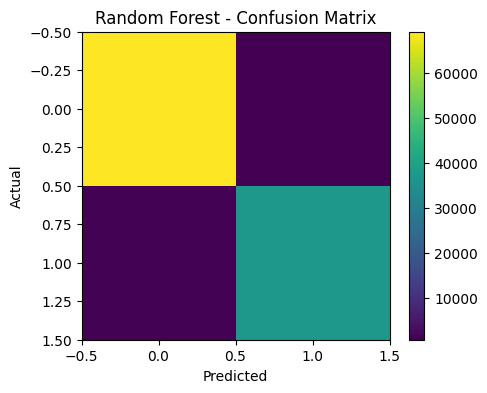


MODEL: XGBoost
Accuracy: 0.9871136643262195
AUC: 0.999233353067417

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     69836
           1       0.99      0.97      0.98     38263

    accuracy                           0.99    108099
   macro avg       0.99      0.98      0.99    108099
weighted avg       0.99      0.99      0.99    108099

Confusion Matrix:
 [[69445   391]
 [ 1002 37261]]


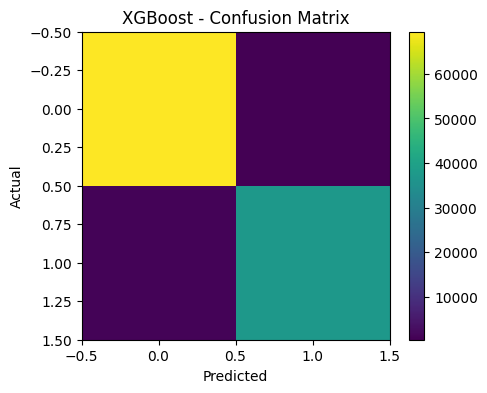


MODEL: Linear SVM (SGD)
Accuracy: 0.9259105079602956
AUC: 0.9528936033478681

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.99      0.95     69836
           1       0.97      0.81      0.89     38263

    accuracy                           0.93    108099
   macro avg       0.94      0.90      0.92    108099
weighted avg       0.93      0.93      0.92    108099

Confusion Matrix:
 [[69016   820]
 [ 7189 31074]]


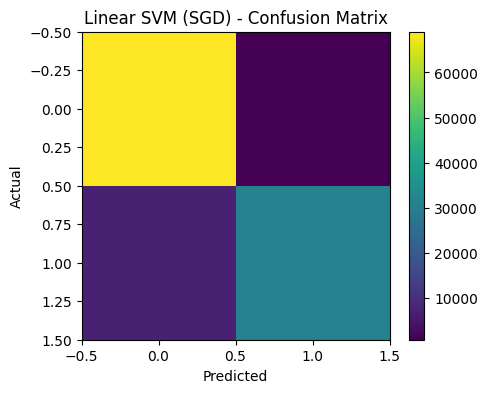


MODEL: Logistic Regression
Accuracy: 0.9270576046031879
AUC: 0.9638158338645653

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.98      0.95     69836
           1       0.97      0.82      0.89     38263

    accuracy                           0.93    108099
   macro avg       0.94      0.90      0.92    108099
weighted avg       0.93      0.93      0.93    108099

Confusion Matrix:
 [[68788  1048]
 [ 6837 31426]]


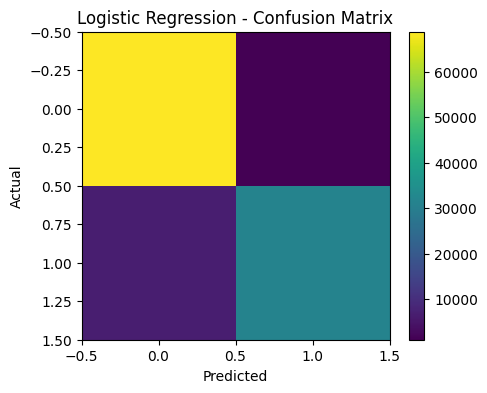


FINAL HYBRID ENSEMBLE RESULTS
Accuracy: 0.9872154228993792
AUC: 0.9990845151458126

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     69836
           1       0.99      0.97      0.98     38263

    accuracy                           0.99    108099
   macro avg       0.99      0.98      0.99    108099
weighted avg       0.99      0.99      0.99    108099

Confusion Matrix:
 [[69433   403]
 [  979 37284]]


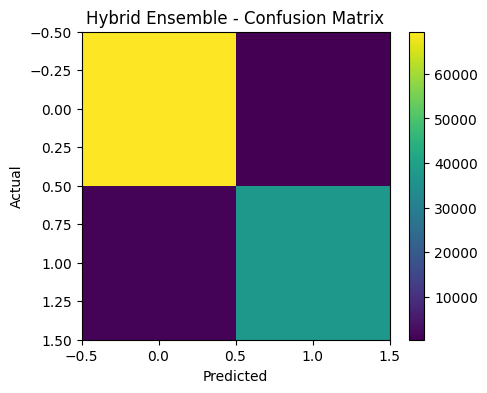

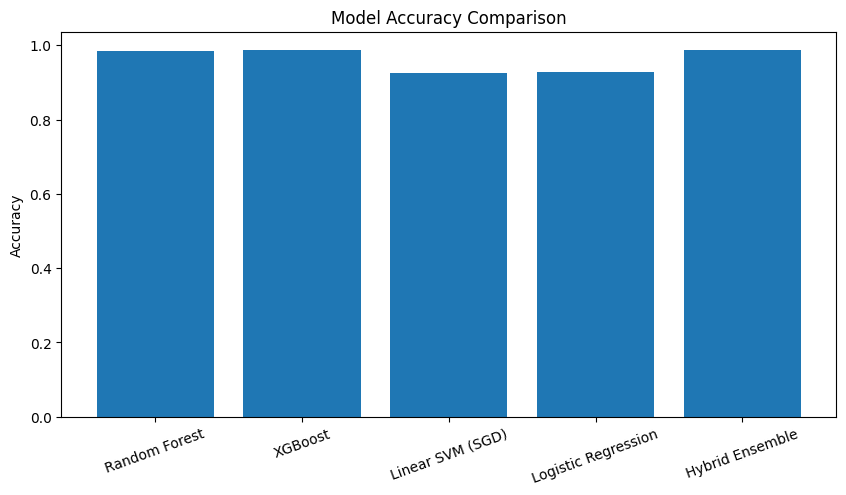

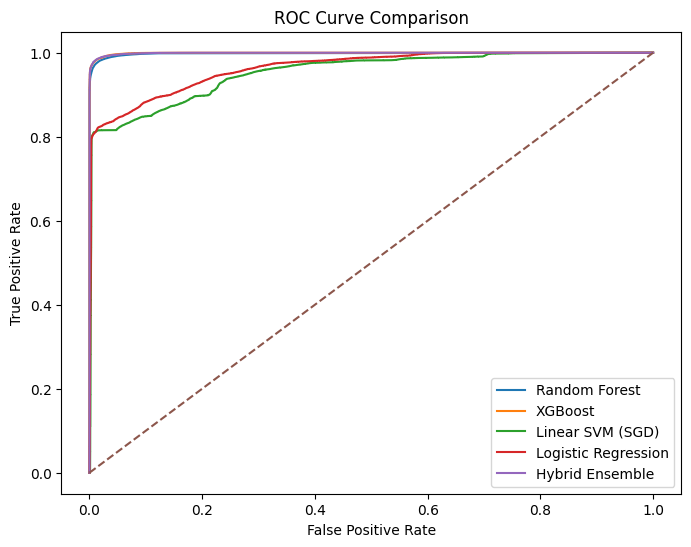


Execution Time: 32.86 minutes


In [ ]:

# =========================================================
# HYBRID ENSEMBLE ARCHITECTURE
# Tree-Based Soft Voting + Linear-Based Hard Voting
# Ridge Regression Meta-Learner
# =========================================================

!pip install xgboost -q

import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold
)

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

from sklearn.ensemble import RandomForestClassifier

from sklearn.linear_model import (
    LogisticRegression,
    SGDClassifier,
    RidgeClassifier
)

from xgboost import XGBClassifier

# =========================================================
# START TIMER
# =========================================================

start_time = time.time()

# =========================================================
# LOAD DATASET
# =========================================================

uploaded = files.upload()

filename = list(uploaded.keys())[0]

if filename.endswith(".csv"):
    df = pd.read_csv(filename)

elif filename.endswith(".parquet"):
    df = pd.read_parquet(filename)

else:
    raise ValueError("Unsupported file format")

print("Dataset Shape:", df.shape)

# =========================================================
# PREPROCESSING
# =========================================================

df = df.dropna()

# Remove label columns safely
X = df.drop(columns=["label", "activity"], errors='ignore')

# Binary Encoding
y = df["label"].map(
    lambda x: 0 if str(x).lower() == "benign" else 1
)

# =========================================================
# FEATURE SCALING
# =========================================================

scaler = StandardScaler()

X = scaler.fit_transform(X.values)
y = y.values

# =========================================================
# TRAIN TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================================================
# BASE MODELS (LEVEL 0)
# =========================================================

# -------------------------
# TREE-BASED MODELS
# -------------------------

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

xgb = XGBClassifier(
    n_estimators=100,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

# -------------------------
# LINEAR-BASED MODELS
# -------------------------

linear_svm = SGDClassifier(
    loss='hinge',
    max_iter=1000,
    tol=1e-3,
    random_state=42,
    n_jobs=-1
)

lr_base = LogisticRegression(
    max_iter=5000,
    random_state=42
)

# =========================================================
# MODEL DICTIONARY
# =========================================================

models = {
    "Random Forest": rf,
    "XGBoost": xgb,
    "Linear SVM (SGD)": linear_svm,
    "Logistic Regression": lr_base
}

results = {}
roc_data = {}

# =========================================================
# TRAIN & EVALUATE INDIVIDUAL MODELS
# =========================================================

for name, model in models.items():

    print(f"\n==============================")
    print(f"MODEL: {name}")
    print(f"==============================")

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    # --------------------------------------------
    # Probability / Decision Scores
    # --------------------------------------------

    if hasattr(model, "predict_proba"):

        prob = model.predict_proba(X_test)[:, 1]

    else:

        prob = model.decision_function(X_test)

        # Normalize to 0-1
        prob = (
            prob - prob.min()
        ) / (
            prob.max() - prob.min() + 1e-8
        )

    # --------------------------------------------
    # Metrics
    # --------------------------------------------

    acc = accuracy_score(y_test, pred)
    auc = roc_auc_score(y_test, prob)

    results[name] = acc
    roc_data[name] = roc_curve(y_test, prob)

    print("Accuracy:", acc)
    print("AUC:", auc)

    print("\nClassification Report:\n")
    print(classification_report(y_test, pred))

    # --------------------------------------------
    # Confusion Matrix
    # --------------------------------------------

    cm = confusion_matrix(y_test, pred)

    print("Confusion Matrix:\n", cm)

    plt.figure(figsize=(5, 4))
    plt.imshow(cm)

    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.colorbar()
    plt.show()

# =========================================================
# STACKING WITH VOTING GROUPS
# =========================================================

kf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Two meta-features:
# Column 0 -> Tree Soft Voting
# Column 1 -> Linear Hard Voting

meta_train = np.zeros((X_train.shape[0], 2))
meta_test = np.zeros((X_test.shape[0], 2))

# =========================================================
# CROSS VALIDATION STACKING
# =========================================================

for train_idx, val_idx in kf.split(X_train, y_train):

    X_tr, X_val = X_train[train_idx], X_train[val_idx]
    y_tr, y_val = y_train[train_idx], y_train[val_idx]

    # --------------------------------------------
    # Train Base Models
    # --------------------------------------------

    rf.fit(X_tr, y_tr)
    xgb.fit(X_tr, y_tr)

    linear_svm.fit(X_tr, y_tr)
    lr_base.fit(X_tr, y_tr)

    # =====================================================
    # GROUP A -> TREE-BASED MODELS
    # SOFT VOTING
    # =====================================================

    rf_prob = rf.predict_proba(X_val)[:, 1]
    xgb_prob = xgb.predict_proba(X_val)[:, 1]

    soft_vote_trees = (
        rf_prob + xgb_prob
    ) / 2

    # =====================================================
    # GROUP B -> LINEAR-BASED MODELS
    # HARD VOTING
    # =====================================================

    svm_pred = linear_svm.predict(X_val)
    lr_pred = lr_base.predict(X_val)

    # Hard Voting Rule
    # If both agree -> use agreed label
    # If disagreement -> classify as attack (1)

    hard_vote_linear = np.where(
        svm_pred == lr_pred,
        svm_pred,
        1
    )

    # --------------------------------------------
    # SAVE META FEATURES
    # --------------------------------------------

    meta_train[val_idx, 0] = soft_vote_trees
    meta_train[val_idx, 1] = hard_vote_linear

# =========================================================
# CREATE TEST META FEATURES
# =========================================================

# Retrain using full training data

rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)

linear_svm.fit(X_train, y_train)
lr_base.fit(X_train, y_train)

# =====================================================
# GROUP A TEST FEATURE
# SOFT VOTING
# =====================================================

meta_test[:, 0] = (
    rf.predict_proba(X_test)[:, 1]
    +
    xgb.predict_proba(X_test)[:, 1]
) / 2

# =====================================================
# GROUP B TEST FEATURE
# HARD VOTING
# =====================================================

svm_test_pred = linear_svm.predict(X_test)
lr_test_pred = lr_base.predict(X_test)

meta_test[:, 1] = np.where(
    svm_test_pred == lr_test_pred,
    svm_test_pred,
    1
)

# =========================================================
# META-LEARNER (LEVEL 2)
# Ridge Regression
# =========================================================

meta_model = RidgeClassifier(
    alpha=1.0,
    random_state=42
)

meta_model.fit(meta_train, y_train)

# =========================================================
# FINAL PREDICTION
# =========================================================

y_pred = meta_model.predict(meta_test)

# RidgeClassifier uses decision_function instead of predict_proba
y_scores = meta_model.decision_function(meta_test)

# Normalize scores to 0-1 for AUC and ROC curve
y_prob = (
    y_scores - y_scores.min()
) / (
    y_scores.max() - y_scores.min() + 1e-8
)

# =========================================================
# FINAL HYBRID RESULTS
# =========================================================

print("\n===================================")
print("FINAL HYBRID ENSEMBLE RESULTS")
print("===================================")

hybrid_acc = accuracy_score(y_test, y_pred)
hybrid_auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", hybrid_acc)
print("AUC:", hybrid_auc)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# =========================================================
# HYBRID CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:\n", cm)

plt.figure(figsize=(5, 4))

plt.imshow(cm)

plt.title("Hybrid Ensemble - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.colorbar()
plt.show()

# =========================================================
# SAVE RESULTS
# =========================================================

results["Hybrid Ensemble"] = hybrid_acc
roc_data["Hybrid Ensemble"] = roc_curve(y_test, y_prob)

# =========================================================
# MODEL ACCURACY COMPARISON
# =========================================================

plt.figure(figsize=(10, 5))

plt.bar(
    results.keys(),
    results.values()
)

plt.xticks(rotation=20)

plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

plt.show()

# =========================================================
# ROC CURVES
# =========================================================

plt.figure(figsize=(8, 6))

for name, (fpr, tpr, _) in roc_data.items():

    plt.plot(fpr, tpr, label=name)

plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

# =========================================================
# EXECUTION TIME
# =========================================================

execution_time = (
    time.time() - start_time
) / 60

print(f"\nExecution Time: {execution_time:.2f} minutes")